In [ ]:
#Importing Libraries

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#database connection


In [ ]:
connection = sqlite3.connect('travel.sqlite')
cursor = connection.cursor()

In [ ]:
cursor.execute("""SELECT name FROM sqlite_master WHERE type='table';""")
print('List of Tables present in the Database')
table_list = [table[0] for table in cursor.fetchall()]
table_list

List of Tables present in the Database


['aircrafts_data',
 'airports_data',
 'boarding_passes',
 'bookings',
 'flights',
 'seats',
 'ticket_flights',
 'tickets']

In [ ]:
#data exploration

In [ ]:
aircrafts_data = pd.read_sql_query(f"""SELECT * FROM aircrafts_data""", connection)
aircrafts_data.head()

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600


In [ ]:
airports_data = pd.read_sql_query(f"""SELECT * FROM aircrafts_data""", connection)
aircrafts_data.head()

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600


In [ ]:
bookings= pd.read_sql_query(f"""SELECT * FROM bookings""", connection)
bookings.head()

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600


In [ ]:
seats = pd.read_sql_query(f"""SELECT * FROM seats""", connection)
seats.head()

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business


In [ ]:
ticket_flights = pd.read_sql_query(f"""SELECT * FROM ticket_flights""", connection)
ticket_flights.head()

,ticket_no,flight_id,fare_conditions,amount
0,0005432159776,30625,Business,42100
1,0005435212351,30625,Business,42100
2,0005435212386,30625,Business,42100
3,0005435212381,30625,Business,42100
4,0005432211370,30625,Business,42100


In [ ]:
for table in table_list:
  print("\ntable: " + table)
  columns_info = connection.execute("PRAGMA table_info({})".format(table))
  for column in columns_info.fetchall():
    print(column[1:3])



table: aircrafts_data
('aircraft_code', 'character(3)')
('model', 'jsonb')
('range', 'INTEGER')

table: airports_data
('airport_code', 'character(3)')
('airport_name', 'jsonb')
('city', 'jsonb')
('coordinates', 'point')
('timezone', 'TEXT')

table: boarding_passes
('ticket_no', 'character(13)')
('flight_id', 'INTEGER')
('boarding_no', 'INTEGER')
('seat_no', 'character varying(4)')

table: bookings
('book_ref', 'character(6)')
('book_date', 'timestamp with time zone')
('total_amount', 'numeric(10,2)')

table: flights
('flight_id', 'INTEGER')
('flight_no', 'character(6)')
('scheduled_departure', 'timestamp with time zone')
('scheduled_arrival', 'timestamp with time zone')
('departure_airport', 'character(3)')
('arrival_airport', 'character(3)')
('status', 'character varying(20)')
('aircraft_code', 'character(3)')
('actual_departure', 'timestamp with time zone')
('actual_arrival', 'timestamp with time zone')

table: seats
('aircraft_code', 'character(3)')
('seat_no', 'character varying(4

In [ ]:
#data cleaning

In [ ]:
for table in table_list:
  print(f'\nMissing Values in table {table}')
  df_table = pd.read_sql_query(f"""SELECT * FROM {table}""", connection)
  print(df_table.isnull().sum())


Missing Values in table aircrafts_data
aircraft_code    0
model            0
range            0
dtype: int64

Missing Values in table airports_data
airport_code    0
airport_name    0
city            0
coordinates     0
timezone        0
dtype: int64

Missing Values in table boarding_passes
ticket_no      0
flight_id      0
boarding_no    0
seat_no        0
dtype: int64

Missing Values in table bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64

Missing Values in table flights
flight_id              0
flight_no              0
scheduled_departure    0
scheduled_arrival      0
departure_airport      0
arrival_airport        0
status                 0
aircraft_code          0
actual_departure       0
actual_arrival         0
dtype: int64

Missing Values in table seats
aircraft_code      0
seat_no            0
fare_conditions    0
dtype: int64

Missing Values in table ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             

In [ ]:
#basic analysis


In [ ]:
#how many planes have more than 100 seats?

In [ ]:
pd.read_sql_query(f"""SELECT aircraft_code, COUNT(*) as num_seats FROM seats GROUP BY aircraft_code HAVING num_seats > 100 ORDER BY num_seats DESC""", connection)

,aircraft_code,num_seats
0,773,402
1,763,222
2,321,170
3,320,140
4,733,130
5,319,116


In [ ]:
# how the number of tickets booked and total amount earned changed with time

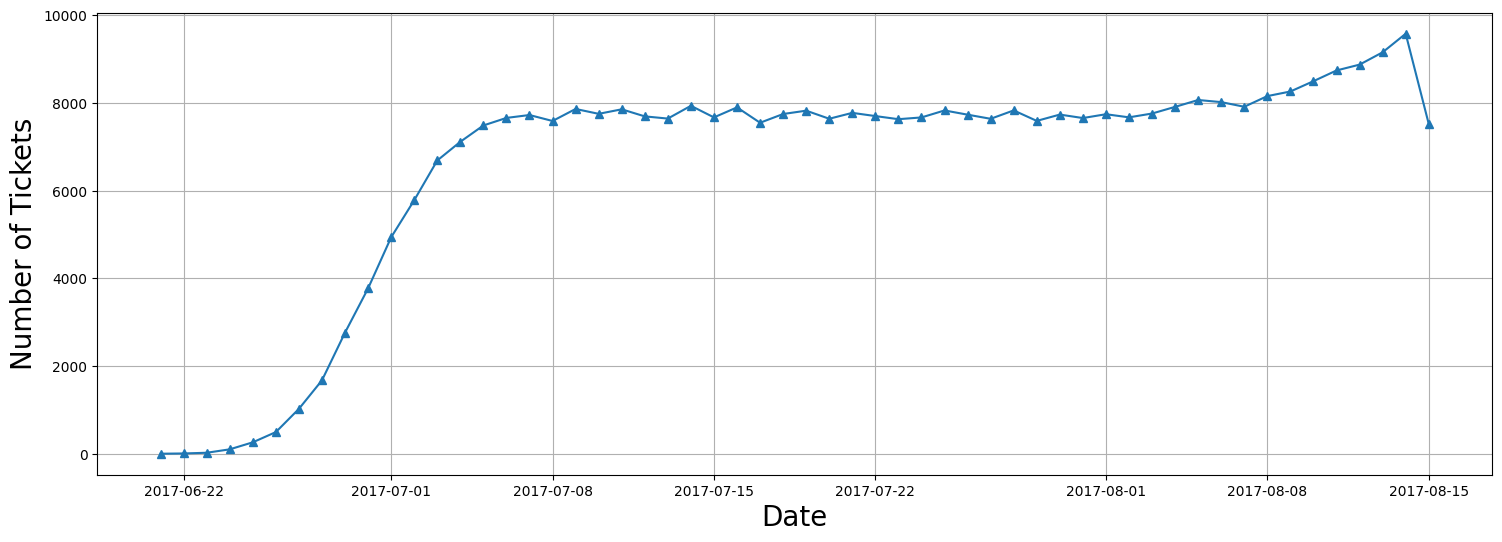

In [ ]:
tickets=pd.read_sql_query(f"""SELECT * FROM tickets INNER JOIN bookings ON tickets.book_ref = bookings.book_ref""", connection)
tickets['book_date'] = pd.to_datetime(tickets['book_date'])
tickets['date'] = tickets['book_date'].dt.date
x = tickets.groupby('date')[['date']].count()
plt.figure(figsize = (18,6))
plt.plot(x.index, x['date'],marker='^')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Number of Tickets', fontsize = 20)
plt.grid('b')
plt.show()

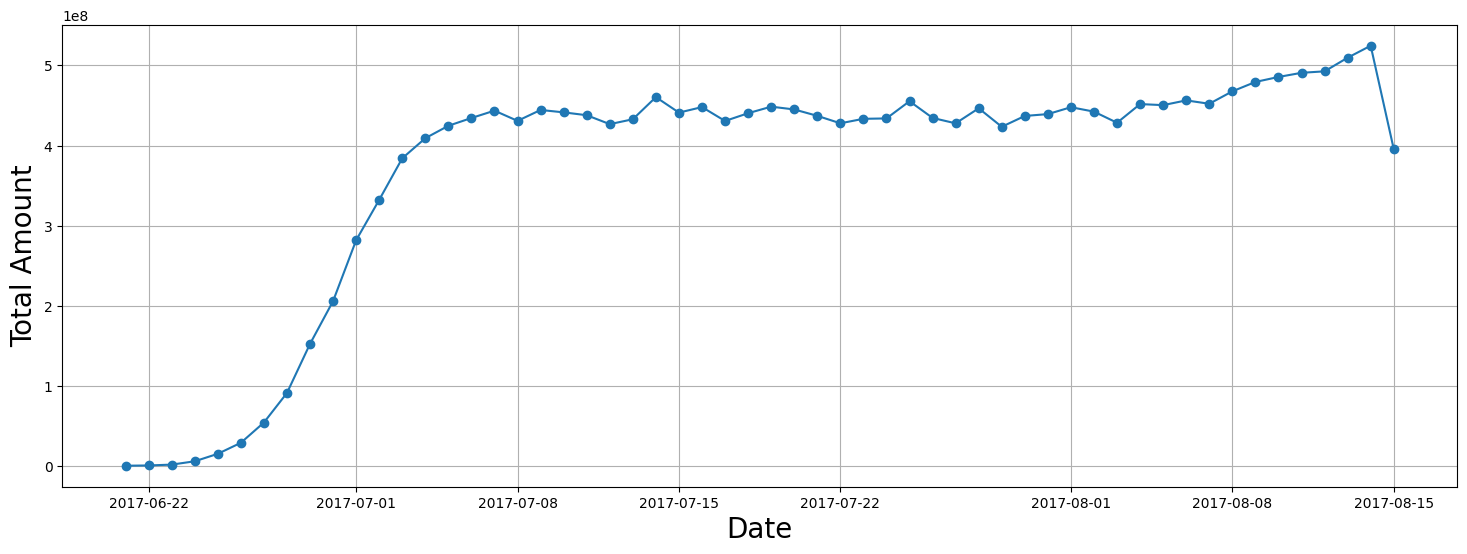

In [ ]:
bookings = pd.read_sql_query(f"""SELECT * FROM bookings""", connection)
bookings['book_date'] = pd.to_datetime(bookings['book_date'])
bookings['date'] = bookings['book_date'].dt.date
y = bookings.groupby('date')[['total_amount']].sum()
plt.figure(figsize = (18,6))
plt.plot(y.index, y['total_amount'],marker='o')
plt.xlabel('Date', fontsize = 20)
plt.ylabel('Total Amount', fontsize = 20)
plt.grid('b')
plt.show()

In [ ]:
#calculate the average charges for each aircraft with different fare conditions

<Axes: xlabel='aircraft_code', ylabel='avg_amount'>

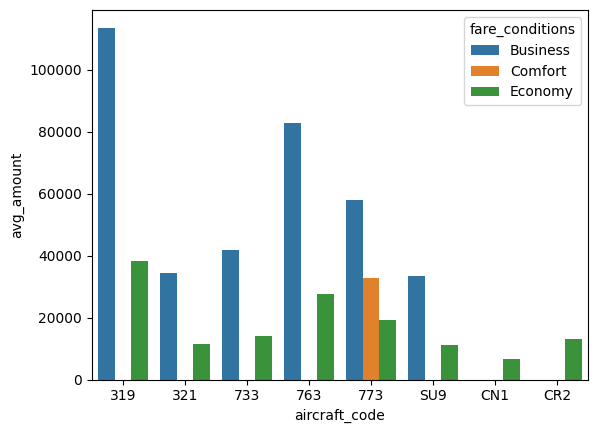

In [ ]:
df= pd.read_sql_query(f""" SELECT fare_conditions, aircraft_code, AVG(amount)as avg_amount FROM ticket_flights JOIN flights
ON ticket_flights.flight_id= flights.flight_id
GROUP BY fare_conditions, aircraft_code """, connection)
sns.barplot(data = df, x = 'aircraft_code', y = 'avg_amount', hue = 'fare_conditions')



In [ ]:
# analysing  occupancy rate

In [ ]:
#for each aircraft , calculating total revenue per year and the avg revenue per ticket

In [ ]:
pd.set_option('display.float_format', str)

In [ ]:
pd.read_sql_query(f""" SELECT aircraft_code, total_revenue, ticket_count, total_revenue/ticket_count as avg_revenue_per_ticket
FROM (SELECT aircraft_code, COUNT(*)as ticket_count, SUM(amount)as total_revenue FROM ticket_flights
JOIN flights ON ticket_flights.flight_id = flights.flight_id
GROUP BY aircraft_code) """, connection)

,aircraft_code,total_revenue,ticket_count,avg_revenue_per_ticket
0,319,2706163100,52853,51201
1,321,1638164100,107129,15291
2,733,1426552100,86102,16568
3,763,4371277100,124774,35033
4,773,3431205500,144376,23765
5,CN1,96373800,14672,6568
6,CR2,1982760500,150122,13207
7,SU9,5114484700,365698,13985


In [ ]:
#calculating the avg occupany per aircraft

In [ ]:
occupancy_rate = pd.read_sql_query(f"""SELECT a.aircraft_code, AVG(a.seats_count)as booked_seats, b.num_seats, AVG(a.seats_count)/b.num_seats as occupancy_rate
FROM (SELECT aircraft_code, flights.flight_id,  COUNT(*) as seats_count FROM boarding_passes
INNER JOIN flights ON boarding_passes.flight_id = flights.flight_id
GROUP BY aircraft_code, flights.flight_id) as a INNER JOIN (SELECT aircraft_code, COUNT(*)as num_seats FROM seats
GROUP BY aircraft_code) as b ON a.aircraft_code = b.aircraft_code
GROUP BY a.aircraft_code""", connection)
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate
0,319,53.58318098720292,116,0.46192397402761143
1,321,88.80923076923077,170,0.5224072398190045
2,733,80.25546218487395,130,0.617349709114415
3,763,113.93729372937294,222,0.5132310528350132
4,773,264.9258064516129,402,0.659019419033863
5,CN1,6.004431314623338,12,0.5003692762186115
6,CR2,21.48284690220174,50,0.42965693804403476
7,SU9,56.81211267605634,97,0.5856918832583128


In [ ]:
#calculating by how much total annual turnover could increase by giving all aircraft a 10% higher occupancy rate

In [ ]:
occupancy_rate['Inc occupancy rate '] = occupancy_rate['occupancy_rate']+ occupancy_rate['occupancy_rate']*0.1
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.58318098720292,116,0.46192397402761143,0.5081163714303726
1,321,88.80923076923077,170,0.5224072398190045,0.574647963800905
2,733,80.25546218487395,130,0.617349709114415,0.6790846800258565
3,763,113.93729372937294,222,0.5132310528350132,0.5645541581185146
4,773,264.9258064516129,402,0.659019419033863,0.7249213609372492
5,CN1,6.004431314623338,12,0.5003692762186115,0.5504062038404727
6,CR2,21.48284690220174,50,0.42965693804403476,0.4726226318484382
7,SU9,56.81211267605634,97,0.5856918832583128,0.644261071584144


In [ ]:
total_revenue = pd.read_sql_query(f"""SELECT aircraft_code, SUM(amount)as total_revenue FROM ticket_flights
JOIN flights ON ticket_flights.flight_id = flights.flight_id
GROUP BY aircraft_code""", connection)
occupancy_rate['Inc occupancy rate '] = total_revenue['total_revenue']/ occupancy_rate['occupancy_rate']*occupancy_rate['Inc occupancy rate ']
occupancy_rate

,aircraft_code,booked_seats,num_seats,occupancy_rate,Inc occupancy rate
0,319,53.58318098720292,116,0.46192397402761143,2976779410.0
1,321,88.80923076923077,170,0.5224072398190045,1801980510.0
2,733,80.25546218487395,130,0.617349709114415,1569207310.0000002
3,763,113.93729372937294,222,0.5132310528350132,4808404810.0
4,773,264.9258064516129,402,0.659019419033863,3774326050.0
5,CN1,6.004431314623338,12,0.5003692762186115,106011180.00000001
6,CR2,21.48284690220174,50,0.42965693804403476,2181036550.0
7,SU9,56.81211267605634,97,0.5856918832583128,5625933169.999999
